# SVR (Support Vector Regression)

보통 회귀 모델은 모든 오차를 줄이려고 한다. 하지만 SVR은 조금 다르게 생각한다.

**이 정도 오차는 괜찮다고 보고, 일정 범위 안의 오차는 크게 문제 삼지 말자.**

이 허용 범위가 바로 `epsilon(ε)` 이다.

즉, SVR은
- 작은 오차는 어느 정도 허용하고
- 그 범위를 벗어난 오차에 더 집중하며
- 필요하면 커널을 사용해 비선형 관계도 학습하는 회귀 모델이다.

## 핵심 용어
- epsilon(ε): 이 정도 오차는 괜찮다고 보는 허용 범위
- C: 허용 범위를 벗어난 오차를 얼마나 엄격하게 벌줄지 정하는 값
- kernel: 직선으로 표현할지, 곡선까지 허용할지 정하는 방식

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 01. SVR 감 잡기

먼저 곡선 형태의 데이터를 만들어서
- 선형 커널
- 다항 커널
- RBF 커널

이 세 가지가 어떻게 다른 모양으로 예측하는지 확인한다.

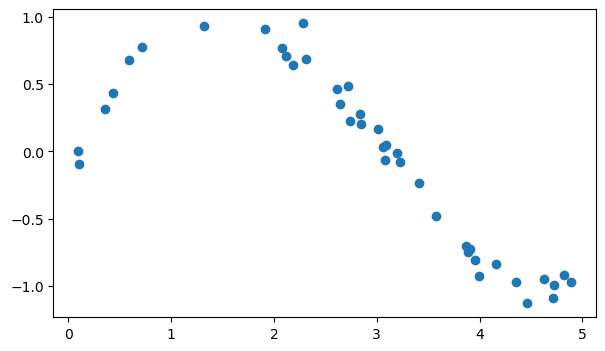

In [2]:
# 샘플 데이터 생성
np.random.seed(0)

X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel() + 0.1 * np.random.randn(40)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, label='data')
plt.show()

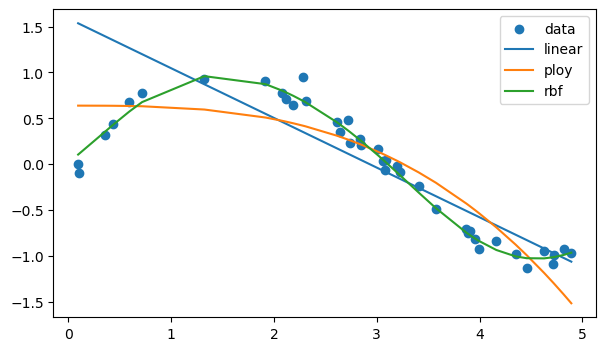

In [3]:
# SVR 모델 학습
from sklearn.svm import SVR

svr_lin = SVR(kernel='linear', C=1.0, epsilon=0.1)      # 선형
svr_poly = SVR(kernel='poly', C=1.0, epsilon=0.1)       # 다항식
svr_rbf = SVR(kernel='rbf', C=1.0, epsilon=0.1)         # RBF

svr_lin.fit(X, y)
svr_poly.fit(X, y)
svr_rbf.fit(X, y)

y_lin = svr_lin.predict(X)
y_ploy = svr_poly.predict(X)
y_rbf = svr_rbf.predict(X)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, label='data')
plt.plot(X, y_lin, label='linear')
plt.plot(X, y_ploy, label='ploy')
plt.plot(X, y_rbf, label='rbf')
plt.legend()
plt.show()

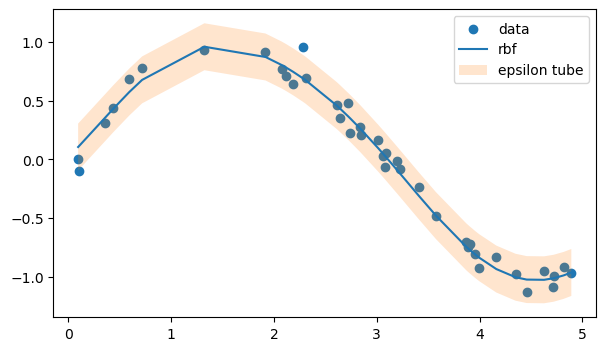

In [4]:
# 허용 오차 범위 시각화
epsilon = 0.2

plt.figure(figsize=(7, 4))
plt.scatter(X, y, label='data')
plt.plot(X, y_rbf, label='rbf')

# X 축에 대해 두 곡선 사이 영역을 채워서 시각화 하는 함수
plt.fill_between(
    X.ravel(),                  # x축 값
    y_rbf - epsilon,            # y축 아래 경계
    y_rbf + epsilon,            # y축 위 경계
    alpha=0.2,
    label='epsilon tube'
)

plt.legend()
plt.show()

## 02. 보스턴 집 값 회귀 문제

실제 회귀 데이터셋에 SVR을 적용해 본다.

1. SVR은 거리 개념을 사용하므로 스케일링이 매우 중요하다.
2. 커널에 따라 성능이 달라질 수 있다.
3. `C`, `epsilon`, `gamma` 같은 하이퍼파라미터가 결과에 영향을 준다.

In [5]:
# 보스턴 집값 데이터 로드
boston_df = pd.read_csv('data/boston_housing_train.csv')

# MEDV를 타겟(집값)으로 사용하고, 나머지 컬럼은 입력 특성으로 사용한다.
X = boston_df.drop('MEDV', axis=1).to_numpy()
y = boston_df['MEDV'].to_numpy()

print(X.shape, y.shape)
print(boston_df.columns.tolist())
print(boston_df.head())

(506, 13) (506,)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [6]:
# 데이터 준비
# SVR은 거리 기반 성격이 강하므로 스케일 차이에 민감하다.
# 특성의 범위가 크게 다르면 특정 특성이 거리 계산에 지나치게 큰 영향을 줄 수 있다.
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train_raw.shape, y_train_raw.shape)
print(X_test_raw.shape, y_test_raw.shape)

print('X 스케일링 전:', X_train_raw[:1])
print('y 스케일링 전:', y_train_raw[:3])

# 회귀에서도 X뿐 아니라 y까지 스케일링해서 학습하는 경우가 있다.
# 특히 SVR처럼 거리와 마진 개념을 쓰는 모델에서는 학습 안정성에 도움이 될 수 있다.
X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train_raw)
X_test = X_scaler.transform(X_test_raw)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

print('X 스케일링 후:', X_train[:1])
print('y 스케일링 후:', y_train[:3])

(404, 13) (404,)
(102, 13) (102,)
X 스케일링 전: [[1.50234e+01 0.00000e+00 1.81000e+01 0.00000e+00 6.14000e-01 5.30400e+00
  9.73000e+01 2.10070e+00 2.40000e+01 6.66000e+02 2.02000e+01 3.49480e+02
  2.49100e+01]]
y 스케일링 전: [12.  19.9 19.4]
X 스케일링 후: [[ 1.28770177 -0.50032012  1.03323679 -0.27808871  0.48925206 -1.42806858
   1.02801516 -0.80217296  1.70689143  1.57843444  0.84534281 -0.07433689
   1.75350503]]
y 스케일링 후: [-1.1583531  -0.3107673  -0.36441197]


In [7]:
from sklearn.metrics import mean_squared_error

# 커널별 비교
svr_lin = SVR(kernel='linear', C=1.0, epsilon=0.1)      # 선형
svr_poly = SVR(kernel='poly', C=1.0, epsilon=0.1)       # 다항식
svr_rbf = SVR(kernel='rbf', C=1.0, epsilon=0.1)         # RBF

svr_lin.fit(X_train, y_train)
svr_poly.fit(X_train, y_train)
svr_rbf.fit(X_train, y_train)

y_lin = svr_lin.predict(X_test)
y_ploy = svr_poly.predict(X_test)
y_rbf = svr_rbf.predict(X_test)

print('linear MSE:', mean_squared_error(y_test, y_lin))
print('poly MSE:', mean_squared_error(y_test, y_ploy))
print('rbf MSE:', mean_squared_error(y_test, y_rbf))

linear MSE: 0.33225625890009464
poly MSE: 0.1601362285771486
rbf MSE: 0.14969164277825783


### MSE를 확인하는 이유

회귀에서는 정답/오답이 아니라 **얼마나 틀렸는가**가 중요하다.  
그래서 커널별로 예측 오차의 크기를 비교하기 위해 MSE를 사용한다.

다만 지금은 `y`를 스케일링한 상태이므로, 이 MSE는 스케일된 기준의 오차이다.  
실제 집값 단위 해석이 필요할 때는 다시 원래 단위로 복원해서 보는 것이 좋다.

In [9]:
# 예측 값을 원래 단위로 복원
y_pred_scaled = svr_rbf.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print("스케일링 된 예측 값 일부 : ", y_pred_scaled[:5])
print("복원 된 예측 값 일부 : ", y_pred[:5])
print("실제 값 일부 : ", y_test_raw[:5])

# 원래 단위 기준으로 오차 확인
rmse_original = np.sqrt(mean_squared_error(y_test_raw, y_pred))
print("원래 단위 RMSE : ", rmse_original)

스케일링 된 예측 값 일부 :  [ 0.29380371  0.95813399 -0.71886209  0.04111154 -0.68412303]
복원 된 예측 값 일부 :  [25.53495868 31.72690901 16.09631559 23.17971845 16.4201042 ]
실제 값 일부 :  [23.6 32.4 13.6 22.8 16.1]
원래 단위 RMSE :  3.6061367879622117


## 03. 하이퍼파라미터 튜닝

SVR에서 자주 보는 핵심 파라미터는 다음과 같다.

- `C`: 튜브 밖 오차를 얼마나 강하게 벌줄지
- `epsilon`: 어느 정도 오차까지 허용할지
- `gamma`: RBF 커널이 데이터 변화에 얼마나 민감하게 반응할지

즉, SVR 튜닝은
"얼마나 엄격하게 맞출 것인가"
"얼마나 유연하게 곡선을 만들 것인가"
를 조절하는 과정이라고 볼 수 있다.

In [13]:
# 하이퍼파라미터 최적화
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel' : ['linear', 'poly', 'rbf'],
    'C' : [0.1, 1, 10, 100],
    'epsilon' : [0.01, 0.1, 1],
    'gamma' : ['scale', 'auto']
}

svr = SVR()

grid_search = GridSearchCV(
    svr,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

In [15]:
# 결과 확인
print('best_params:', grid_search.best_params_)
print('best_score(MSE):', -1 * grid_search.best_score_)

# 베스트 모델로 학습
best_model = grid_search.best_estimator_

y_pred_scaled = best_model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print("스케일링 된 예측 값 일부 : ", y_pred_scaled[:5])
print("복원 된 예측 값 일부 : ", y_pred[:5])
print("실제 값 일부 : ", y_test_raw[:5])

# 원래 단위 기준으로 오차 확인
rmse_original = np.sqrt(mean_squared_error(y_test_raw, y_pred))
print("원래 단위 RMSE : ", rmse_original)

best_params: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}
best_score(MSE): 0.12085983556079354
스케일링 된 예측 값 일부 :  [ 0.36811128  0.99928239 -0.86594519 -0.07875021 -0.71731314]
복원 된 예측 값 일부 :  [26.22754908 32.11043646 14.72541431 22.06253621 16.11075276]
실제 값 일부 :  [23.6 32.4 13.6 22.8 16.1]
원래 단위 RMSE :  3.444003448474891


## 정리

1. SVR은 모든 오차를 똑같이 줄이려는 회귀가 아니다.
2. 일정 범위(`epsilon`) 안의 작은 오차는 허용하는 관점이 있다.
3. 선형/다항/RBF 커널에 따라 예측 곡선의 유연성이 달라진다.
4. SVR은 스케일링의 영향을 크게 받으므로 전처리가 중요하다.
5. `C`, `epsilon`, `gamma`를 조절하면서 오차와 일반화 성능의 균형을 맞춘다.